In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = sns.load_dataset('healthexp') 

df.head(10)

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
8,1971,Japan,163.854,72.9
9,1971,USA,357.988,71.2


In [18]:
# 4. Nettoyage
df['Country'] = df['Country'].astype(str)
df['Country'] = df['Country'].str.strip()
df['Country'] = df['Country'].str.title()


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


In [3]:
print(df.dtypes)
print(df.head())

Year                 int64
Country                str
Spending_USD       float64
Life_Expectancy    float64
dtype: object
   Year        Country  Spending_USD  Life_Expectancy
0  1970        Germany       252.311             70.6
1  1970         France       192.143             72.2
2  1970  Great Britain       123.993             71.9
3  1970          Japan       150.437             72.0
4  1970            USA       326.961             70.9


In [4]:
df["Country"].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

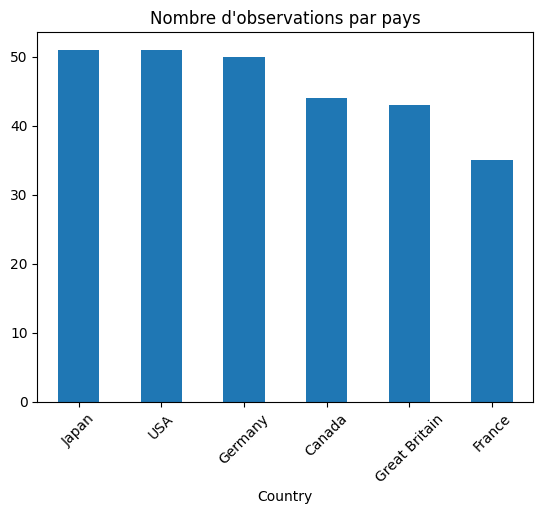

In [5]:
df["Country"].value_counts().plot(kind= "bar")

plt.title("Nombre d'observations par pays")
plt.xticks(rotation=45)
plt.show()

In [6]:
print(df["Spending_USD"].describe())


count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64


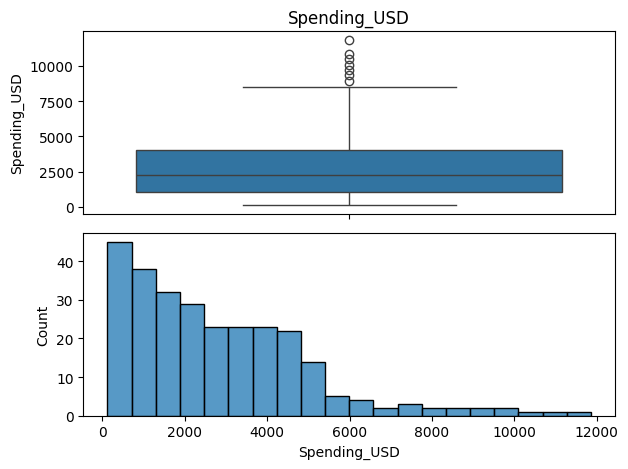

In [7]:
fig, axes = plt.subplots(2, 1)  # 2 rows, 1 column

sns.histplot(df["Spending_USD"], bins=20, ax=axes[1])

sns.boxplot(y=df["Spending_USD"], ax=axes[0])
axes[0].set_title("Spending_USD")

plt.tight_layout()
plt.show()

In [8]:
print(df["Life_Expectancy"].describe())

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64


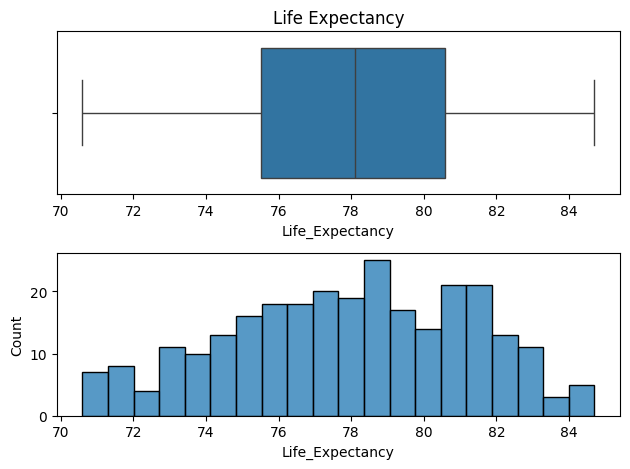

In [9]:
fig, axes = plt.subplots(2, 1)  # 2 rows, 1 column

sns.histplot(df["Life_Expectancy"], bins=20, ax=axes[1])

sns.boxplot(x=df["Life_Expectancy"], ax=axes[0])
axes[0].set_title("Life Expectancy")

plt.tight_layout()
plt.show()

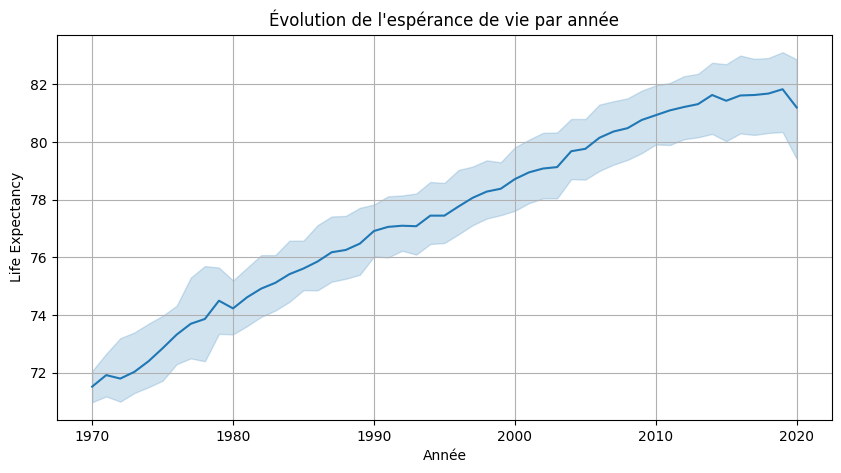

In [10]:
plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="Year", y="Life_Expectancy")

plt.title("Évolution de l'espérance de vie par année")
plt.xlabel("Année")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()

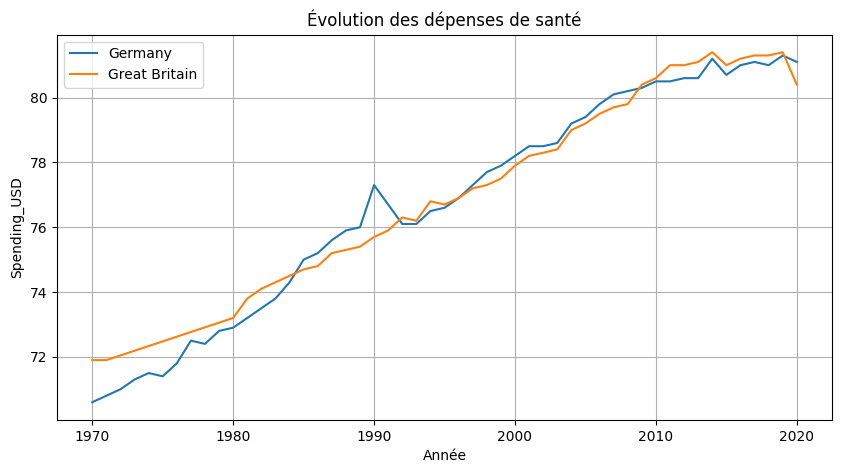

In [11]:
subset = df[df["Country"].isin(["Germany", "Great Britain"])]
plt.figure(figsize=(10,5))
sns.lineplot(data=subset, x="Year", y="Life_Expectancy" , hue="Country")

plt.title("Évolution des dépenses de santé")
plt.xlabel("Année")
plt.ylabel("Spending_USD")
plt.legend()
plt.grid(True)

plt.show()

<Axes: xlabel='Country', ylabel='Life_Expectancy'>

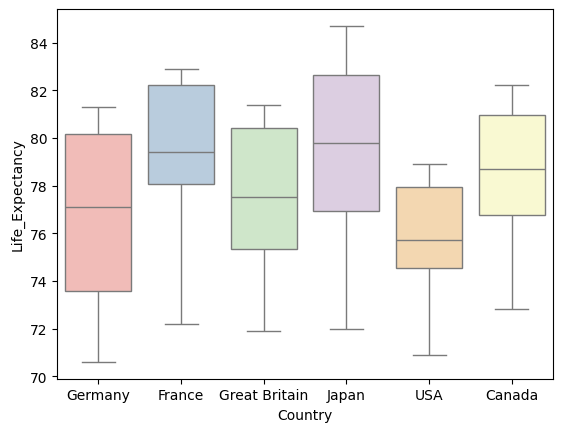

In [12]:
sns.boxplot(data= df , y='Life_Expectancy', x='Country', hue= 'Country', palette="Pastel1")

In [13]:
df.groupby("Country")["Life_Expectancy"].describe()

,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Canada,44.0,78.706818,2.502222,72.8,76.775,78.7,80.975,82.2
France,35.0,79.565714,2.862120,72.2,78.050,79.4,82.200,82.9
Germany,50.0,76.726000,3.473915,70.6,73.575,77.1,80.175,81.3
Great Britain,43.0,77.620930,2.827548,71.9,75.350,77.5,80.400,81.4
Japan,51.0,79.554902,3.547242,72.0,76.950,79.8,82.650,84.7
USA,51.0,75.843137,2.336258,70.9,74.550,75.7,77.950,78.9


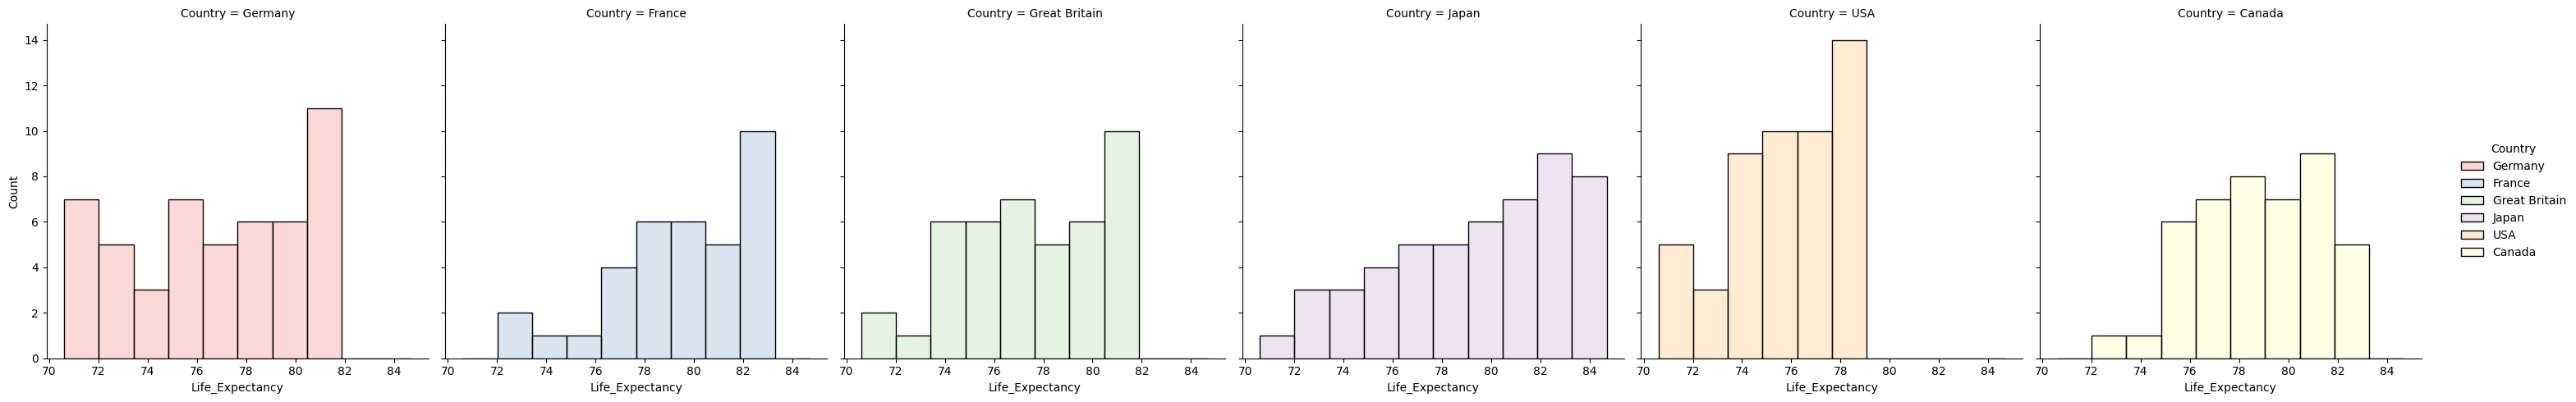

In [14]:

sns.displot(data= df , x= 'Life_Expectancy', col='Country', hue="Country", palette="Pastel1")

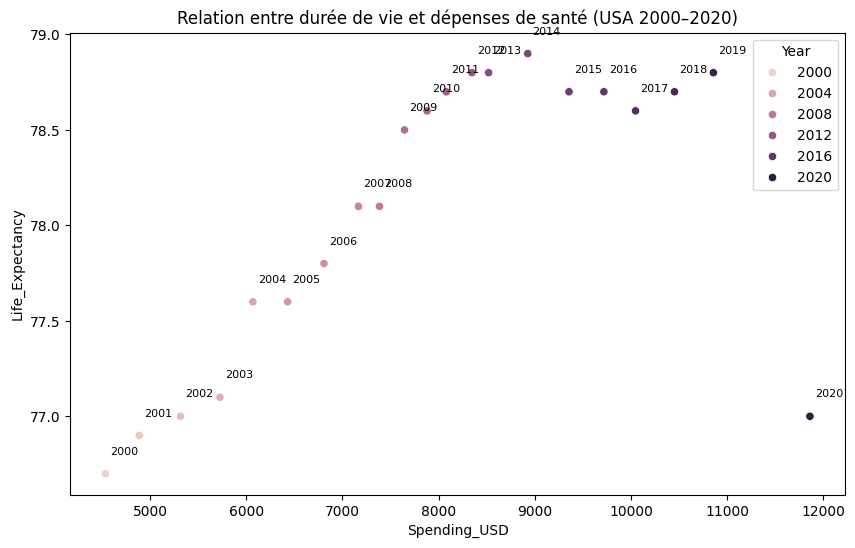

In [15]:
USA = df[(df["Country"] == "USA") & 
         (df["Year"] >= 2000) & 
         (df["Year"] <= 2020)]

plt.figure(figsize=(10,6))

sns.scatterplot(data=USA, x="Spending_USD", y="Life_Expectancy", hue="Year")

plt.title("Relation entre durée de vie et dépenses de santé (USA 2000–2020)")

for i in range(len(USA)):
    plt.text(
        USA["Spending_USD"].iloc[i] + 50,
        USA["Life_Expectancy"].iloc[i] + 0.1,
        str(USA["Year"].iloc[i]),
        fontsize=8
    )

plt.show()

In [16]:
#Corrélation entre dépenses et espérance de vie
from scipy.stats import pearsonr

usa = df[
    (df["Country"] == "USA") & 
    (df["Year"] >= 2000) & 
    (df["Year"] <= 2020)
]

corr, p_value = pearsonr(usa["Spending_USD"], usa["Life_Expectancy"])

print("Corrélation :", corr)
print("p-value :", p_value)

Corrélation : 0.6210674528998253
p-value : 0.0026581544805799064


In [19]:
import pandas as pd
import numpy as np

# Filtrer les États-Unis depuis 1970
usa = df[
    (df["Country"] == "Usa") & 
    (df["Year"] >= 1970)
].sort_values("Year")

# Calculer les variations annuelles
usa["diff"] = usa["Life_Expectancy"].diff()

# Supprimer les valeurs NaN
diff = usa["diff"].dropna()

# Calcul des statistiques
mean_diff = diff.mean()          # moyenne observée
std_diff = diff.std(ddof=1)      # écart-type
n = len(diff)                    # taille échantillon

# Calcul de la statistique t
t_stat = (mean_diff - 0.3) / (std_diff / np.sqrt(n))

# Seuil critique (alpha = 0.02, test bilatéral)
t_crit = 2.33  # approximation pour 98%

# Affichage
print("Moyenne observée :", mean_diff)
print("Écart-type :", std_diff)
print("Nombre d'années :", n)
print("t-statistique :", t_stat)

# 8️⃣ Décision
if abs(t_stat) > t_crit:
    print("On rejette H0 : l'affirmation du politicien est fausse")
else:
    print("On ne rejette pas H0 : l'affirmation est possible")

Moyenne observée : 0.12199999999999989
Écart-type : 0.33823672425189577
Nombre d'années : 50
t-statistique : -3.7212105613188773
On rejette H0 : l'affirmation du politicien est fausse
